# Anomaly-Based Network Intrusion Detection System
## Notebook 04: Classical Machine Learning Models

Trains and evaluates Logistic Regression, Random Forest, and XGBoost.
Compares results and saves the best model.

## 1. Imports

In [1]:
import os, sys, warnings, joblib
warnings.filterwarnings('ignore')
PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score)

from src.evaluation.metrics import evaluate_model, plot_roc_curve, plot_confusion_matrix

MODELS_DIR = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Ready')

Ready


## 2. Load Data

In [2]:
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
FEAT_DIR = os.path.join(PROJECT_ROOT, 'data', 'features')

X_train = pd.read_csv(f'{DATA_DIR}/X_train.csv')
X_val   = pd.read_csv(f'{DATA_DIR}/X_val.csv')
X_test  = pd.read_csv(f'{DATA_DIR}/X_test.csv')
y_train = pd.read_csv(f'{DATA_DIR}/y_train.csv').squeeze()
y_val   = pd.read_csv(f'{DATA_DIR}/y_val.csv').squeeze()
y_test  = pd.read_csv(f'{DATA_DIR}/y_test.csv').squeeze()

SELECTED = joblib.load(f'{FEAT_DIR}/selected_features.pkl')

X_tr = X_train[SELECTED]
X_va = X_val[SELECTED]
X_te = X_test[SELECTED]

print(f'Train {X_tr.shape}  Val {X_va.shape}  Test {X_te.shape}')

Train (122738, 30)  Val (26301, 30)  Test (26302, 30)


## 3. Define Models

In [3]:
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, solver='lbfgs', max_iter=1000, random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=10,
        random_state=42, n_jobs=-1),

    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1,
        eval_metric='logloss', verbosity=0),
}

print(f'{len(models)} models defined')

3 models defined


## 4. Train and Evaluate

In [4]:
results = {}

for name, model in models.items():
    print(f'\nTraining {name} ...')
    model.fit(X_tr, y_train)

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    results[name] = evaluate_model(y_test, y_pred, y_prob)
    results[name]['model'] = model

    print(f'  Accuracy : {results[name]["accuracy"]:.4f}')
    print(f'  F1 Score : {results[name]["f1"]:.4f}')
    print(f'  ROC-AUC  : {results[name]["roc_auc"]:.4f}')


Training Logistic Regression ...


Accuracy  : 0.9444
Precision : 0.9458
Recall    : 0.9741
F1 Score  : 0.9597
ROC-AUC   : 0.9819
PR-AUC    : 0.9905

              precision    recall  f1-score   support

      Normal       0.94      0.88      0.91      8400
      Attack       0.95      0.97      0.96     17902

    accuracy                           0.94     26302
   macro avg       0.94      0.93      0.93     26302
weighted avg       0.94      0.94      0.94     26302

  Accuracy : 0.9444
  F1 Score : 0.9597
  ROC-AUC  : 0.9819

Training Random Forest ...


Accuracy  : 0.9765
Precision : 0.9673
Recall    : 0.9992
F1 Score  : 0.9830
ROC-AUC   : 0.9976
PR-AUC    : 0.9988

              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96      8400
      Attack       0.97      1.00      0.98     17902

    accuracy                           0.98     26302
   macro avg       0.98      0.96      0.97     26302
weighted avg       0.98      0.98      0.98     26302

  Accuracy : 0.9765
  F1 Score : 0.9830
  ROC-AUC  : 0.9976

Training XGBoost ...


Accuracy  : 0.9874
Precision : 0.9887
Recall    : 0.9929
F1 Score  : 0.9908
ROC-AUC   : 0.9994
PR-AUC    : 0.9997

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      8400
      Attack       0.99      0.99      0.99     17902

    accuracy                           0.99     26302
   macro avg       0.99      0.98      0.99     26302
weighted avg       0.99      0.99      0.99     26302

  Accuracy : 0.9874
  F1 Score : 0.9908
  ROC-AUC  : 0.9994


## 5. Compare Models


Model Comparison:


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.9444,0.9458,0.9741,0.9597,0.9819
Random Forest,0.9765,0.9673,0.9992,0.9830,0.9976
XGBoost,0.9874,0.9887,0.9929,0.9908,0.9994


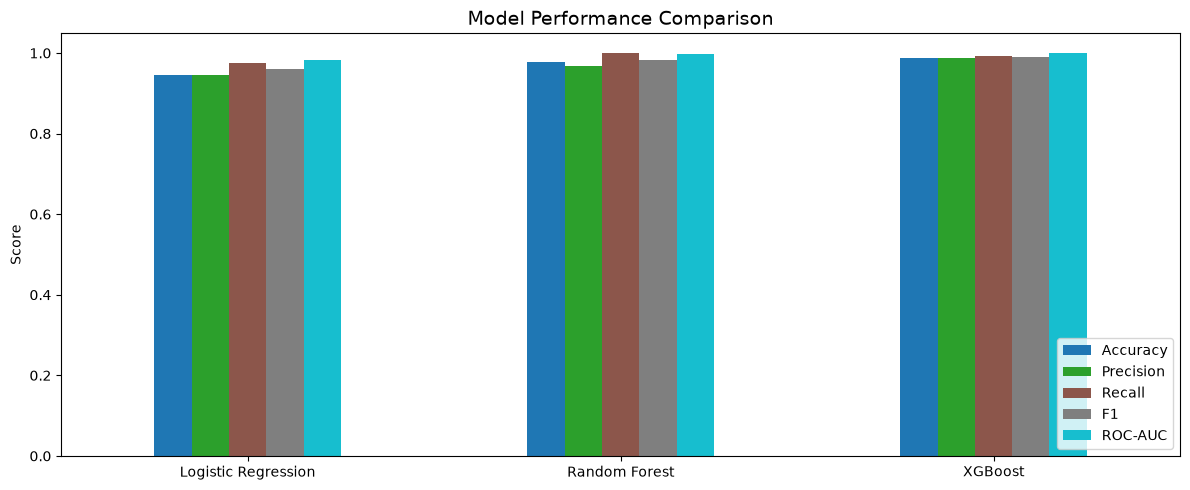

In [5]:
comparison = pd.DataFrame({
    name: {
        'Accuracy':  res['accuracy'],
        'Precision': res['precision'],
        'Recall':    res['recall'],
        'F1':        res['f1'],
        'ROC-AUC':   res['roc_auc'],
    }
    for name, res in results.items() if name != 'model'
}).T.round(4)

print('\nModel Comparison:')
display(comparison)

comparison.drop(columns=['model'], errors='ignore').plot(
    kind='bar', figsize=(12, 5), colormap='tab10')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Confusion Matrices

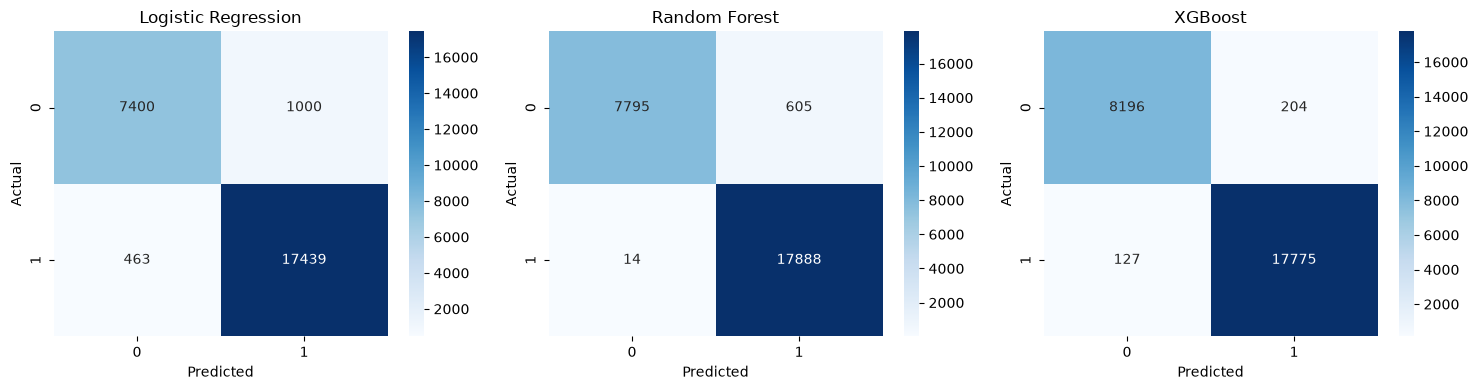

In [6]:
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['model'].predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 7. Feature Importance (XGBoost)

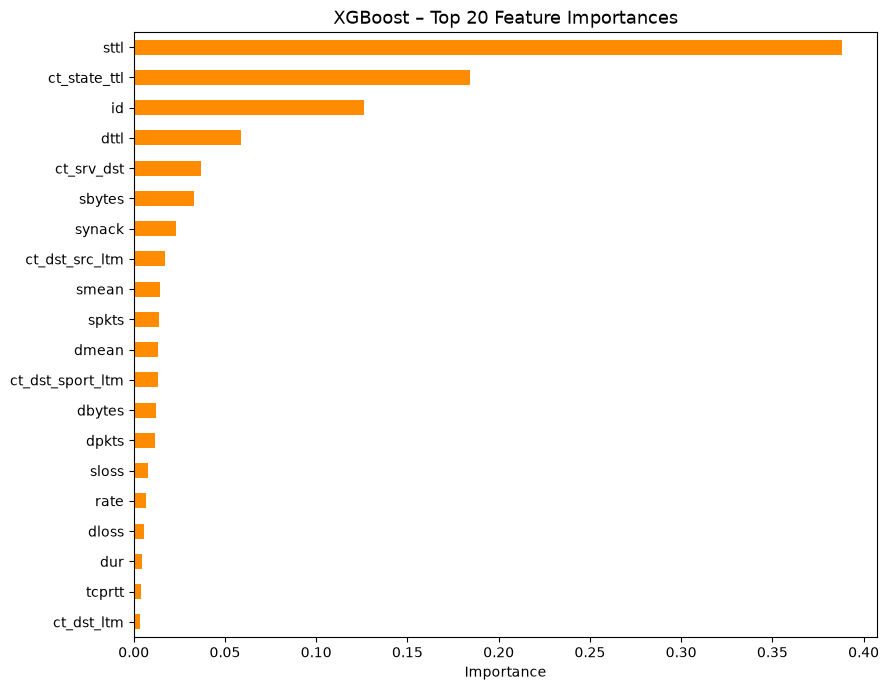

In [7]:
xgb_model = results['XGBoost']['model']
importance = pd.Series(xgb_model.feature_importances_, index=SELECTED)
top20 = importance.nlargest(20)

plt.figure(figsize=(9, 7))
top20.sort_values().plot(kind='barh', color='darkorange')
plt.title('XGBoost – Top 20 Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. Save Best Model

In [8]:
best_name = comparison['F1'].idxmax()
best_model = results[best_name]['model']

joblib.dump(best_model, f'{MODELS_DIR}/best_classical_model.pkl')
comparison.to_csv(f'{RESULTS_DIR}/classical_model_comparison.csv')

print(f'Best model: {best_name}')
print(f'Saved to   : {MODELS_DIR}/best_classical_model.pkl')
print('Next: 05_dl_models.ipynb')

Best model: XGBoost
Saved to   : D:\Github\Anomaly-Based-Neetwork-Intrusion-Detection-System\models/best_classical_model.pkl
Next: 05_dl_models.ipynb
